# 03. Обучение и выбор модели

**Цель:** выбрать модель по validation AP (average precision).
**Условия:** общие OTE-признаки, все положительные и 39% отрицательных с обратными весами отбора. Optuna и ранняя остановка используют только validation.

[Итоговый отчёт](../reports/full/RESULTS.md)

## Настройка

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import joblib
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").exists() and (p / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Запустите notebook из корня проекта или notebooks")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import importlib.metadata
import matplotlib.pyplot as plt
import optuna
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from aml.workflow import load_split, ranking_metrics, lightgbm_validation, resolve_run, new_run, set_active
RUN_DIR = resolve_run(PROJECT_ROOT)
DATA_DIR = RUN_DIR / "data"
TRAIN_DIR = new_run(RUN_DIR, "training")
STORAGE = "sqlite:///" + (TRAIN_DIR / "optuna.sqlite3").as_posix()
SEED = 42
NEGATIVE_SAMPLE_RATIO = 0.39
CATBOOST_TRIALS, LIGHTGBM_TRIALS, XGBOOST_TRIALS = 20, 30, 20
EARLY_STOPPING_ROUNDS = 100
ITERATIONS = 1200
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Загрузка признаков

In [2]:
X_train, y_train = load_split("train", DATA_DIR)
X_val, y_val = load_split("val", DATA_DIR)
manifest = json.loads((RUN_DIR / "data_manifest.json").read_text())
for features, labels in [(X_train, y_train), (X_val, y_val)]:
    if list(features.columns) != manifest["features"] or not np.isfinite(features.to_numpy()).all():
        raise ValueError("Feature schema or values differ from manifest")
    if labels.nunique() != 2:
        raise ValueError("Both classes required for training and validation")
print("Train/val:", X_train.shape, X_val.shape)


Train/val: (4846503, 65) (692487, 65)


## Обучающая выборка

In [3]:
y_array = y_train.to_numpy()
positive_positions = np.flatnonzero(y_array == 1)
negative_positions = np.flatnonzero(y_array == 0)

rng = np.random.default_rng(SEED)
negative_sample_size = max(
    1,
    int(NEGATIVE_SAMPLE_RATIO * len(negative_positions)),
)
sampled_negative_positions = rng.choice(
    negative_positions,
    size=negative_sample_size,
    replace=False,
)

fit_positions = np.sort(
    np.concatenate([positive_positions, sampled_negative_positions])
)

X_fit = X_train.iloc[fit_positions].reset_index(drop=True)
y_fit = y_train.iloc[fit_positions].reset_index(drop=True)

negative_weight = len(negative_positions) / negative_sample_size
sample_weight = np.where(
    y_fit.to_numpy() == 0,
    negative_weight,
    1.0,
).astype("float32")

sampling_summary = pd.Series(
    {
        "full_train_rows": len(X_train),
        "fit_rows": len(X_fit),
        "fit_fraction": len(X_fit) / len(X_train),
        "positive_rows_kept": int((y_fit == 1).sum()),
        "negative_rows_sampled": int((y_fit == 0).sum()),
        "negative_sampling_ratio": NEGATIVE_SAMPLE_RATIO,
        "negative_inverse_weight": negative_weight,
    },
    name="weighted undersampling",
)

sampling_summary

full_train_rows            4.846503e+06
fit_rows                   1.891497e+06
fit_fraction               3.902808e-01
positive_rows_kept         2.231000e+03
negative_rows_sampled      1.889266e+06
negative_sampling_ratio    3.900000e-01
negative_inverse_weight    2.564103e+00
Name: weighted undersampling, dtype: float64

## Метрики

Основная метрика — AP; ROC-AUC используется дополнительно.

In [4]:
# AP is non-interpolated average precision, distinct from trapezoidal PR-AUC.
validation_scores = {}
trained_models = {}


## Обучение моделей

### Logistic Regression

Стандартизация обучается только на fit-выборке с учётом весов.

In [5]:
lr_scaler = StandardScaler()

X_fit_lr = lr_scaler.fit(X_fit, sample_weight=sample_weight).transform(X_fit)
X_val_lr = lr_scaler.transform(X_val)

logistic_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=SEED,
)

logistic_model.fit(
    X_fit_lr,
    y_fit,
    sample_weight=sample_weight,
)

validation_scores["Logistic Regression"] = logistic_model.predict_proba(
    X_val_lr
)[:, 1]
trained_models["Logistic Regression"] = Pipeline([("scaler", lr_scaler), ("model", logistic_model)])

ranking_metrics(
    y_val,
    validation_scores["Logistic Regression"],
)

{'AP': 0.1406620288289544, 'ROC-AUC': 0.9505940866184572}

### CatBoost

In [7]:
def objective_catboost(trial: optuna.Trial) -> float:

    model = CatBoostClassifier(
        iterations=ITERATIONS,
        learning_rate=trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float(
            "l2_leaf_reg", 0.5, 20.0, log=True
        ),
        random_strength=trial.suggest_float(
            "random_strength", 1e-3, 5.0, log=True
        ),
        bagging_temperature=trial.suggest_float(
            "bagging_temperature", 0.0, 3.0
        ),
        loss_function="Logloss",
        eval_metric="PRAUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
        thread_count=4,
    )

    model.fit(
        X_fit,
        y_fit,
        sample_weight=sample_weight,
        eval_set=(X_val, y_val),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    )


    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


cat_study = optuna.create_study(
    study_name="cat", storage=STORAGE,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

cat_study.optimize(
    objective_catboost,
    n_trials=CATBOOST_TRIALS,
    show_progress_bar=True,
)

cat_study.trials_dataframe().to_csv(TRAIN_DIR / "cat_trials.csv", index=False)

pd.Series(
    {
        "best_validation_AP": cat_study.best_value,
        **cat_study.best_params,
    },
    name="CatBoost tuning",
)


best_validation_AP     0.296989
learning_rate          0.032684
depth                  8.000000
l2_leaf_reg            7.441632
random_strength        0.163840
bagging_temperature    0.468056
Name: CatBoost tuning, dtype: float64

In [8]:
catboost_model = CatBoostClassifier(
    **cat_study.best_params,
    iterations=ITERATIONS,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=SEED,
    allow_writing_files=False,
    verbose=False,
    thread_count=4,
)

catboost_model.fit(
    X_fit,
    y_fit,
    sample_weight=sample_weight,
    eval_set=(X_val, y_val),
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)

validation_scores["CatBoost"] = catboost_model.predict_proba(X_val)[:, 1]
trained_models["CatBoost"] = catboost_model

ranking_metrics(y_val, validation_scores["CatBoost"])

{'AP': 0.29698908402060176, 'ROC-AUC': 0.976379029835176}

### LightGBM

`positive_boost` задаёт дополнительный вес положительного класса.

In [9]:
def objective_lightgbm(trial: optuna.Trial) -> float:
    positive_boost = trial.suggest_float(
        "positive_boost", 1.0, 30.0, log=True
    )

    params = {
        "n_estimators": ITERATIONS,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 10, 100, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 20, 300, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.65, 1.0
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.65, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-3, 20.0, log=True
        ),
        "objective": "binary",
        "metric": "average_precision",
        "verbosity": -1,
        "n_jobs": 4,
        "random_state": SEED,
    }

    weights = sample_weight.copy()
    weights[y_fit.to_numpy() == 1] *= positive_boost

    model = LGBMClassifier(**params)
    model.fit(
        X_fit,
        y_fit,
        sample_weight=weights,
        **lightgbm_validation(X_val, y_val),
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
        ],
    )

    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


lgb_study = optuna.create_study(
    study_name="lgb", storage=STORAGE,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

lgb_study.optimize(
    objective_lightgbm,
    n_trials=LIGHTGBM_TRIALS,
    show_progress_bar=True,
)

lgb_study.trials_dataframe().to_csv(TRAIN_DIR / "lgb_trials.csv", index=False)

pd.Series(
    {
        "best_validation_AP": lgb_study.best_value,
        **lgb_study.best_params,
    },
    name="LightGBM tuning",
)


best_validation_AP      0.313478
positive_boost         18.792686
learning_rate           0.036249
num_leaves             21.000000
max_depth              10.000000
min_child_samples     295.000000
subsample               0.940407
colsample_bytree        0.774385
reg_alpha               0.000634
reg_lambda              1.581866
Name: LightGBM tuning, dtype: float64

In [10]:
lgb_best_params = lgb_study.best_params.copy()
lgb_positive_boost = lgb_best_params.pop("positive_boost")

lgb_model = LGBMClassifier(
    **lgb_best_params,
    n_estimators=ITERATIONS,
    subsample_freq=1,
    objective="binary",
    metric="average_precision",
    verbosity=-1,
    n_jobs=4,
    random_state=SEED,
)

lgb_weights = sample_weight.copy()
lgb_weights[y_fit.to_numpy() == 1] *= lgb_positive_boost

lgb_model.fit(
    X_fit,
    y_fit,
    sample_weight=lgb_weights,
    **lightgbm_validation(X_val, y_val),
    eval_metric="average_precision",
    callbacks=[
        lgb.early_stopping(
            EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
    ],
)

validation_scores["LightGBM"] = lgb_model.predict_proba(X_val)[:, 1]
trained_models["LightGBM"] = lgb_model

ranking_metrics(y_val, validation_scores["LightGBM"])

{'AP': 0.31347847560510617, 'ROC-AUC': 0.9788466718256689}

### XGBoost

In [11]:
def objective_xgboost(trial: optuna.Trial) -> float:
    positive_boost = trial.suggest_float(
        "positive_boost", 1.0, 30.0, log=True
    )

    model = XGBClassifier(
        n_estimators=ITERATIONS,
        learning_rate=trial.suggest_float(
            "learning_rate", 0.015, 0.12, log=True
        ),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        min_child_weight=trial.suggest_float(
            "min_child_weight", 1.0, 100.0, log=True
        ),
        subsample=trial.suggest_float(
            "subsample", 0.65, 1.0
        ),
        colsample_bytree=trial.suggest_float(
            "colsample_bytree", 0.65, 1.0
        ),
        gamma=trial.suggest_float(
            "gamma", 1e-5, 5.0, log=True
        ),
        reg_alpha=trial.suggest_float(
            "reg_alpha", 1e-5, 10.0, log=True
        ),
        reg_lambda=trial.suggest_float(
            "reg_lambda", 1e-3, 20.0, log=True
        ),
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        max_bin=128,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        n_jobs=4,
        scale_pos_weight=positive_boost,
        random_state=SEED,
    )

    model.fit(
        X_fit,
        y_fit,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    scores = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, scores)


xgb_study = optuna.create_study(
    study_name="xgb", storage=STORAGE,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

xgb_study.optimize(
    objective_xgboost,
    n_trials=XGBOOST_TRIALS,
    show_progress_bar=True,
)

xgb_study.trials_dataframe().to_csv(TRAIN_DIR / "xgb_trials.csv", index=False)

pd.Series(
    {
        "best_validation_AP": xgb_study.best_value,
        **xgb_study.best_params,
    },
    name="XGBoost tuning",
)


best_validation_AP    0.320489
positive_boost        1.539243
learning_rate         0.058079
max_depth             8.000000
min_child_weight      6.167806
subsample             0.823744
colsample_bytree      0.883752
gamma                 0.000238
reg_alpha             0.022964
reg_lambda            0.037638
Name: XGBoost tuning, dtype: float64

In [12]:
xgb_best_params = xgb_study.best_params.copy()
xgb_positive_boost = xgb_best_params.pop("positive_boost")

xgb_model = XGBClassifier(
    **xgb_best_params,
    n_estimators=ITERATIONS,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    max_bin=128,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    n_jobs=4,
    scale_pos_weight=xgb_positive_boost,
    random_state=SEED,
)

xgb_model.fit(
    X_fit,
    y_fit,
    sample_weight=sample_weight,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

validation_scores["XGBoost"] = xgb_model.predict_proba(X_val)[:, 1]
trained_models["XGBoost"] = xgb_model

ranking_metrics(y_val, validation_scores["XGBoost"])

{'AP': 0.3204893399861193, 'ROC-AUC': 0.9772531239694984}

## Сравнение на validation

In [13]:
validation_results = pd.DataFrame(
    {
        model_name: ranking_metrics(y_val, scores)
        for model_name, scores in validation_scores.items()
    }
).T.sort_values("AP", ascending=False)

champion_name = validation_results.index[0]

print(f"Champion by validation AP: {champion_name}")
validation_results.style.format("{:.4f}")

Champion by validation AP: XGBoost


,AP,ROC-AUC
XGBoost,0.3205,0.9773
LightGBM,0.3135,0.9788
CatBoost,0.2970,0.9764
Logistic Regression,0.1407,0.9506


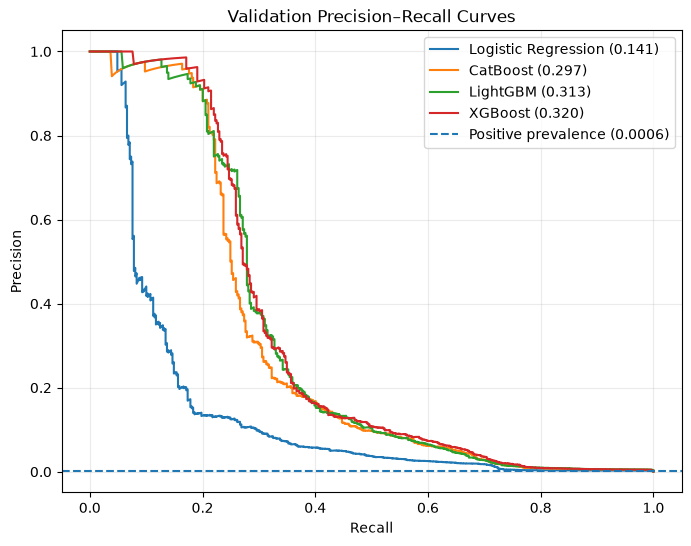

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, scores in validation_scores.items():
    precision, recall, _ = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    ax.plot(
        recall,
        precision,
        label=f"{model_name} ({pr_auc:.3f})",
    )

ax.axhline(
    y_val.mean(),
    linestyle="--",
    label=f"Positive prevalence ({y_val.mean():.4f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation Precision–Recall Curves")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Сохранение результатов

Сохраняются кандидаты, champion, параметры и история Optuna. Порог выбирается в notebook 04.

In [15]:
champion = trained_models[champion_name]
bundle = {"model": champion, "name": champion_name, "run_id": manifest["run_id"],
          "features": manifest["features"], "seed": SEED,
          "versions": {p: importlib.metadata.version(p) for p in
              ["scikit-learn", "catboost", "lightgbm", "xgboost", "pandas", "numpy"]}}
joblib.dump(bundle, TRAIN_DIR / "champion.joblib")
validation_results.to_csv(TRAIN_DIR / "validation_metrics.csv")
print("Saved champion:", champion_name)
for model_name, model in trained_models.items():
    joblib.dump(model, TRAIN_DIR / (model_name.replace(" ", "_") + ".joblib"))
config = {"seed": SEED, "negative_sample_ratio": NEGATIVE_SAMPLE_RATIO,
    "iterations": ITERATIONS, "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "best_parameters": {"CatBoost": cat_study.best_params,
        "LightGBM": lgb_study.best_params, "XGBoost": xgb_study.best_params,
        "Logistic Regression": logistic_model.get_params()}}
(TRAIN_DIR / "configuration.json").write_text(json.dumps(config, indent=2))
set_active(RUN_DIR, "active_training.json", TRAIN_DIR)


Saved champion: XGBoost


## Выводы

- По validation выбран XGBoost: AP 0,3205 против 0,3135 у LightGBM.
- CatBoost получил AP 0,2970, Logistic Regression — 0,1407.
- Разрыв лидеров мал; устойчивость проверяется в notebook 06. Лучшие параметры на одном validation не гарантируют превосходства в будущем.